# Chapter - 4.1 Coding an LLM architecture

##### we will specify the configuration of the small GPT-2 model via the following Python dictionary, which we will use in the code examples below

In [1]:
GPT_CONFIG_124M={
    "vocab_size":50257,
    "context_length":1024,
    "emb_dim":768,
    "n_heads":12,
    "n_layers":12,
    "drop_rate":0.1,
    "qkv_bias":False
}

######  implementing a GPT placeholder architecture (DummyGPTModel) for  big-picture view of how everything fits together and what other components we need to code in the upcoming sections to assemble the full GPT model architecture

### 4.1 A placeholder GPT model architecture class

In [2]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb= nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb=nn.Dropout(cfg["drop_rate"])
        self.trf_blocks=nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm= DummyLayerNorm(cfg["emb_dim"])
        self.out_head=nn.Linear(
            cfg["emb_dim"],cfg["vocab_size"],bias=False
        )
    def forward(self,in_idx):
        batch_size,seq_len= in_idx.shape
        token_emebds=self.tok_emb(in_idx)
        pos_embeds=self.pos_emb(torch.arange(seq_len,device=in_idx.device))
        x=token_emebds+ pos_embeds
        x=self.drop_emb(x)
        x=self.trf_blocks(x)
        x=self.final_norm(x)
        logits=self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()

    def forward(self,x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self,normalized_shape,eps=1e-5):
        super().__init__()

    def forward(self,x):
        return x

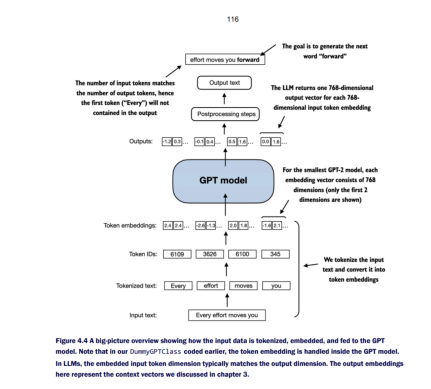

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.4.png")

plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
import torch
import tiktoken

In [5]:
tokenizer = tiktoken.get_encoding("gpt2")
batch=[]
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch=torch.stack(batch,dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


##### the first row corresponds to the first text, and the second row corresponds to the second text

##### Next, we initialize a new 124 million parameter DummyGPTModel instance and feed it the tokenized batch:


In [6]:
torch.manual_seed(123)
model=DummyGPTModel(GPT_CONFIG_124M)
logits=model(batch)
print("output shape:",logits.shape)
print(logits)

output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


In [7]:
logits[0]

tensor([[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
        [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
        [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
        [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],
       grad_fn=<SelectBackward0>)

In [8]:
logits[0].shape

torch.Size([4, 50257])

In [9]:
logits[0][0].shape

torch.Size([50257])

##### the output tensor has two rows corresponding to the two text samples. Each text sampleconsists of 4 tokens; each token is a 50,257-dimensional vector, which matches the size of the tokenizer's vocabulary.

##### the embedding has 50,257 dimensions because each of these dimensions refers to a unique token in the vocabulary. At the end of this chapter, when we implement the postprocessing code, we will convert these 50,257-dimensional vectors back into token IDs, which we can then decode into words.

##### Now that we have taken a top-down look at the GPT architecture and its in- and outputs, we will code the individual placeholders in the upcoming sections, starting with the real layer normalization class that will replace the DummyLayerNorm in the previous code.

### 4.2 Normalizing activations with layer normalization

##### deep neural networks are difficult to train because vanishing and exploding gradients make weight updates unstable, preventing the model from learning effectively.**

##### to solve that problem ,we will implement layer normalization to improve the stability and efficiency of neural network training.

##### the main idea behind layer normalization is to adjust the activations (outputs) of a neural network layer to have a mean of 0 and a variance of 1, also known as unit variance.

##### this adjustment speeds up the convergence to effective weights and ensures consistent,reliable training

##### layerNorm is applied before each Multi-Head Attention module, before each Feed-Forward Network, and once before the final output layer to stabilize activations and improve training.

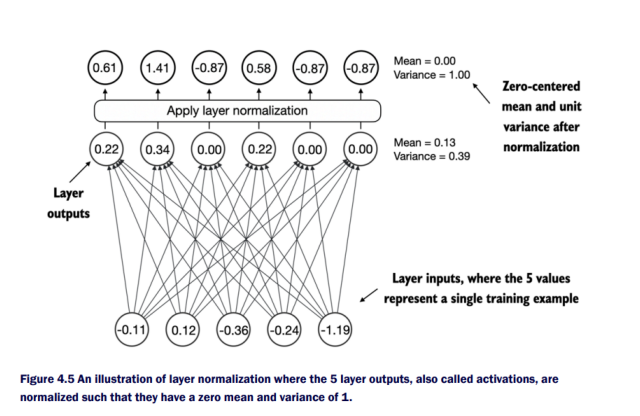

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.5.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### we can recreate the example shown in Figure 4.5 via the following code, where we implement a neural network layer with 5 inputs and 6 outputs that we apply to two input examples:

In [11]:
torch.manual_seed(123)
batch_example=torch.rand(2,5)  #batch size = 2; each sample is a 5-dimensional input vector
print(batch_example)

tensor([[0.2961, 0.5166, 0.2517, 0.6886, 0.0740],
        [0.8665, 0.1366, 0.1025, 0.1841, 0.7264]])


In [12]:
layer=nn.Sequential(nn.Linear(5,6),nn.ReLU())  #creates a neural network layer that transforms a 5D input into a 6D output using a Linear layer followed by ReLU.

In [13]:
layer

Sequential(
  (0): Linear(in_features=5, out_features=6, bias=True)
  (1): ReLU()
)

##### the neural network layer we have coded consists of a Linear layer followed by a non-linear activation function, ReLU (short for Rectified Linear Unit), which is a standard activation function in neural networks

In [14]:
out=layer(batch_example)
print(out)

tensor([[0.0000, 0.0000, 0.4091, 0.6587, 0.3914, 0.0000],
        [0.0000, 0.0000, 0.1902, 0.3182, 0.6486, 0.0000]],
       grad_fn=<ReluBackward0>)


##### as we can see, each output is of 6 dim

In [15]:
out[0].shape

torch.Size([6])

##### what we did now was create a neural network that takes a 5-dimensional input, transformed it into a 6-dimensional output using a linear layer, and then applied the ReLU activation function to produce the final 6-dimensional output.

#### basically till here, the highlighted section

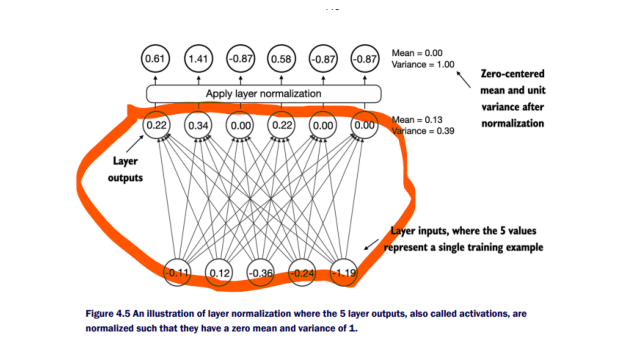

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.6.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### before we apply layer normalization to these outputs, let's examine the mean and variance:

In [17]:
mean=out.mean(dim=-1,keepdim=True)
var=out.var(dim=-1,keepdim=True)
print("mean:" ,mean)
print("variance:" ,var)

mean: tensor([[0.2432],
        [0.1928]], grad_fn=<MeanBackward1>)
variance: tensor([[0.0799],
        [0.0670]], grad_fn=<VarBackward0>)


#### so as we can see,
##### First training example (first row): Mean = 0.2432
##### Second training example (second row): Mean = 0.1928
##### First training example (first row): Variance = 0.0799
##### Second training example (second row): Variance = 0.0670

## Understanding `dim` when computing the mean (or variance)

Suppose we have the following tensor:

```python
out = torch.tensor([
    [0.22, 0.34, 0.00, 0.22, 0.00, 0.00],
    [0.21, 0.23, 0.00, 0.51, 0.32, 0.00]
])
```

The shape of this tensor is:

```text
(2, 6)
```

- **2 rows** → 2 training examples (batch size = 2)
- **6 columns** → 6 features (or activations) for each example

---

## Case 1: `dim=1` (or `dim=-1`)

```python
mean = out.mean(dim=1)
```

This computes the mean **across the columns**, meaning each row is averaged independently.

### Input 1

```text
0.22  0.34  0.00  0.22  0.00  0.00
 └────────────── Average these ──────────────┘
```

Mean = **0.13**

### Input 2

```text
0.21  0.23  0.00  0.51  0.32  0.00
 └────────────── Average these ──────────────┘
```

Mean = **0.21**

Result:

```python
tensor([0.13, 0.21])
```

Each training example gets **its own mean**.

This is exactly what **Layer Normalization** needs.

---

## Case 2: `dim=0`

```python
mean = out.mean(dim=0)
```

This computes the mean **down the rows**, meaning each column is averaged independently.

### Column 1

```text
0.22
0.21
────
Mean = 0.21
```

### Column 2

```text
0.34
0.23
────
Mean = 0.29
```

### Column 3

```text
0.00
0.00
────
Mean = 0.00
```

...

Result:

```python
tensor([0.21, 0.29, 0.00, 0.37, 0.16, 0.00])
```

Here, each **feature (column)** gets its own mean.

---

## Why does LayerNorm use `dim=-1`?

Suppose our tensor has shape:

```python
out.shape
```

```text
torch.Size([2, 6])
```

Each row represents one training example.

LayerNorm should normalize **each training example independently**, so it computes:

```python
mean = out.mean(dim=-1, keepdim=True)
```

This produces:

```text
Input 1 → Mean = 0.13
Input 2 → Mean = 0.21
```

These means are then used to normalize each row separately.

---

## Why `dim=-1` instead of `dim=1`?

For a **2D tensor**, `dim=1` and `dim=-1` are identical because the last dimension is dimension 1.

However, GPT does not work with 2D tensors. It uses tensors with shape:

```text
(batch_size, sequence_length, embedding_dimension)
```

For example:

```text
(2, 4, 768)
```

where:

- `dim=0` → Batch dimension
- `dim=1` → Sequence (tokens)
- `dim=2` → Embedding dimension

or equivalently:

- `dim=-1` → Embedding dimension (the last dimension)

LayerNorm should normalize **each token's embedding vector**, so it always computes the mean and variance along the **last dimension**.

Using `dim=-1` makes the code work correctly for both 2D tensors and higher-dimensional tensors.

---

## Summary

- **`dim=0`** → Compute the mean (or variance) **down each column** (one value per feature).
- **`dim=1`** → Compute the mean (or variance) **across each row** (one value per training example).
- **`dim=-1`** → Compute the mean (or variance) along the **last dimension**. For a 2D tensor, this is the same as `dim=1`. For GPT's 3D tensors, it means normalizing each token's embedding vector independently.

##### now ,apply layer normalization to the layer outputs we obtained earlier. The operation consists of subtracting the mean and dividing by the square root of the variance (also known as standard deviation):

In [18]:
out_norm=(out-mean)/ torch.sqrt(var)

In [19]:
print(out_norm)

tensor([[-0.8603, -0.8603,  0.5869,  1.4698,  0.5242, -0.8603],
        [-0.7450, -0.7450, -0.0102,  0.4844,  1.7608, -0.7450]],
       grad_fn=<DivBackward0>)


#### the values are now normalized, now lets recheck the men and varince.

In [20]:
mean=out_norm.mean(dim=-1,keepdim=True)
var=out_norm.var(dim=-1,keepdim=True)
print("mean:" ,mean)
print("variance:" ,var)

mean: tensor([[-3.9736e-08],
        [-1.9868e-08]], grad_fn=<MeanBackward1>)
variance: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


##### note that, the mean values [-3.9736e-08] and  [-1.9868e-08] are values very close to zero,To improve readability, we can also turn off the scientific notation when printing tensorvalues by setting sci_mode to False:

In [21]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


##### now we can see that, after applying the normalization our means and variance are 0 and 1 respectively

##### we have coded and applied layer normalization in a step-by-step process. Let's now encapsulate this process in a PyTorch module that we can use in the GPT model later:

In [23]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5 #keeps the denominator non-zero and makes the computation numerically stable.
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

##### Without scale and shift, every layer would always output values with mean 0 and variance 1. That normalization is useful for stable training, but it's also restrictive. The learnable scale and shift let the model keep the training benefits of normalization while still learning whatever output distribution is most useful for the task

##### the final output of LayerNorm is: output=scale×normalized_value+shift

##### **BIASED VARIANCE**

###### In our variance calculation method, we have opted for an implementation detail by setting `unbiased=False`. For those curious about what this means, in the variance calculation, we divide by the number of inputs `n` in the variance formula. This approach does not apply Bessel's correction, which typically uses `n−1` instead of `n` in the denominator to adjust for bias in sample variance estimation. This decision results in a so-called biased estimate of the variance. For large-scale language models (LLMs), where the embedding dimension `n` is significantly large, the difference between using `n` and `n−1` is practically negligible. We chose this approach to ensure compatibility with the GPT-2 model's normalization layers and because it reflects TensorFlow's default behavior, which was used to implement the original GPT-2 model. Using a similar setting ensures our method is compatible with the pretrained weights we will load in chapter 6.


##### now try the LayerNorm module in practice and apply it to the batch input:

In [25]:
ln=LayerNorm(emb_dim=5) #instantiate the normlayer

out_ln=ln(batch_example) 
mean=out_ln.mean(dim=-1,keepdim=True)
var=out_ln.var(dim=-1,unbiased=False, keepdim=True)
print("mean: ",mean)
print("var:", var)

mean:  tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
var: tensor([[0.9998],
        [0.9999]], grad_fn=<VarBackward0>)


##### In this section, we covered one of the building blocks we will need to implement the GPT architecture, as shown in the mental model in Figure 4.7.

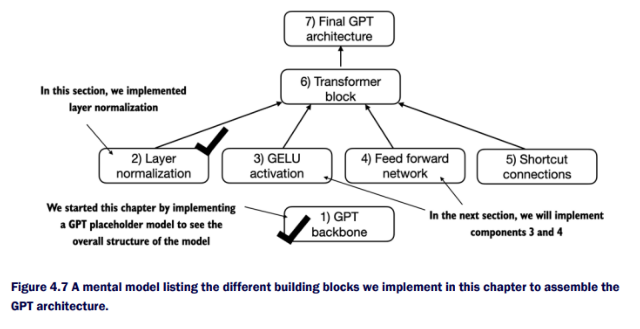

In [26]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("4.7.png")

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

##### In the next section, we will look at the GELU activation function, which is one of theactivation functions used in LLMs, instead of the traditional ReLU function we used in this section.


##### lAYER NORMALIZATION VERSUS BATCH NORMALIZATION

#####  Unlike batch normalization, which normalizes across the batch dimension, layer normalization normalizes across the feature dimension. LLMs often require significant computational resources, and the available hardware or the specific use case can dictate the batch size during training or inference. Since layer normalization normalizes each input independently of the batch size, it offers more flexibility and stability in these scenarios. This is particularly beneficial for distributed training or when deploying models in environments where resources are constrained